In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('mymoviedb.csv',lineterminator="\n")

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [7]:
df.isnull().sum()  #Identify missing Values

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [8]:
df.duplicated()  #identify duplicated row 

0       False
1       False
2       False
3       False
4       False
        ...  
9822    False
9823    False
9824    False
9825    False
9826    False
Length: 9827, dtype: bool

In [9]:
df.drop_duplicates(inplace=True)  #Remove duplicated rows

# Exploration Summary
# we have a dataframe consistency of 9827 rows and 9 columns.
# our dataset looks a bit tidy with no naNs nor duplicated values.
# Release_Date column needs to be casted into date time and tp extract only the year value.
# overview,original_Language and poster url wouldn't be so useful during analusis, so we'll drop them.
# there is noticable outliers in popularity column
# vote_Avarage better be categorised for proper analysis.
# Genrw column has comma seperated values and white spaces that needs to be handled and casted into category.

In [10]:
df['Release_Date']=pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[us]


In [11]:
df['Release_Date']=df['Release_Date'].dt.year
print(df['Release_Date'].dtypes)

int32


In [12]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [13]:
#Remove Unnecccessary column
df.drop(columns=['Overview','Original_Language','Poster_Url'],inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [14]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


# categorizing Vote_Avarage column

we would cut the Volt_Average values and make 4 categories: Popilar  Average  Below_Avg  NOT_popular to describe it more using catigorize_col() function provided above.

In [16]:
def catigorize_col(df,col,labels):
    edges=[df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']
          ]
    df[col]=pd.cut(df[col],edges,labels=labels,duplicates='drop')
    return df

In [17]:
labels=['not_popular','below_avg','average','popular']
catigorize_col(df,'Vote_Average',labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [18]:
df['Vote_Average']=df['Vote_Average'].astype('object')
df['Vote_Average'].dtypes

dtype('O')

In [19]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [20]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [21]:
df.dropna(inplace=True)  # drop null values
df.isnull().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

# we'd split genres into a list and then explode our dataframe to have only one genre per row for each movie

In [22]:
df['Genre']=df['Genre'].str.split(', ')
df=df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [24]:
# casting column into cateogry

df['Genre']=df['Genre'].astype('object')

df['Genre'].dtypes

dtype('O')

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  25552 non-null  int32  
 1   Title         25552 non-null  str    
 2   Popularity    25552 non-null  float64
 3   Vote_Count    25552 non-null  int64  
 4   Vote_Average  25552 non-null  object 
 5   Genre         25552 non-null  object 
dtypes: float64(1), int32(1), int64(1), object(2), str(1)
memory usage: 1.1+ MB


In [26]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

# Data Visualization

In [27]:
sns.set_style('whitegrid')

 # what is the most frequent genre of movies released on Netflix ?

In [28]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

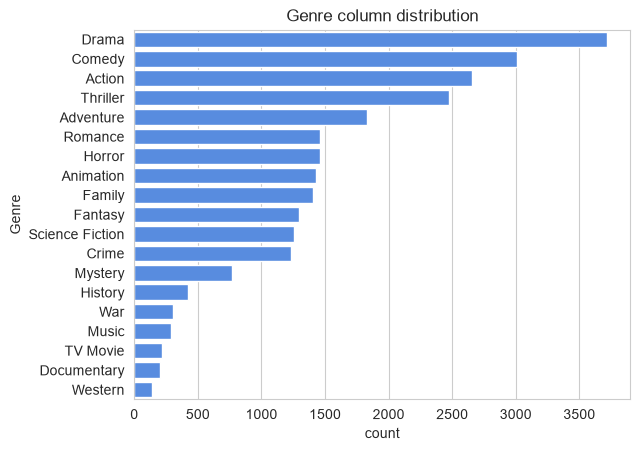

In [84]:
sns.countplot(y='Genre',data=df, order=df['Genre'].value_counts().index,color='#4287f5')
plt.title("Genre column distribution")
plt.show()

# which has highest votes in vote_avg column ?

In [30]:
df['Vote_Average'].describe()

count       25552
unique          4
top       average
freq         6613
Name: Vote_Average, dtype: object

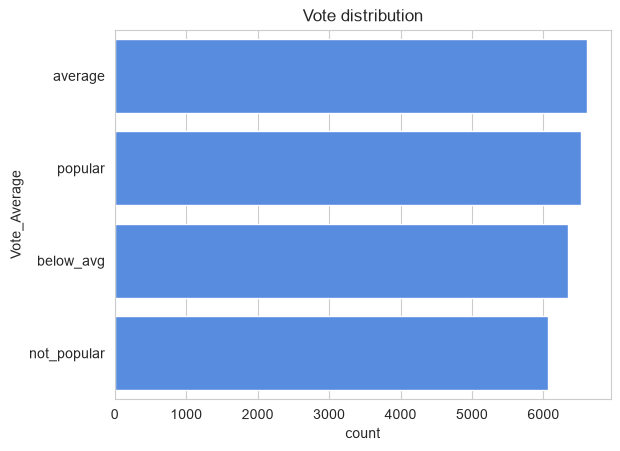

In [54]:
sns.countplot(y='Vote_Average',data=df, order=df['Vote_Average'].value_counts().index,color='#4287f5')
plt.title("Vote distribution")
plt.show()

# what movie got the highest popularity ? what's its genre ?

In [73]:
df[df['Popularity']==df['Popularity'].max()][['Title','Popularity','Genre']]

,Title,Popularity,Genre
0,Spider-Man: No Way Home,5083.0,Action
1,Spider-Man: No Way Home,5083.0,Adventure
2,Spider-Man: No Way Home,5083.0,Science Fiction


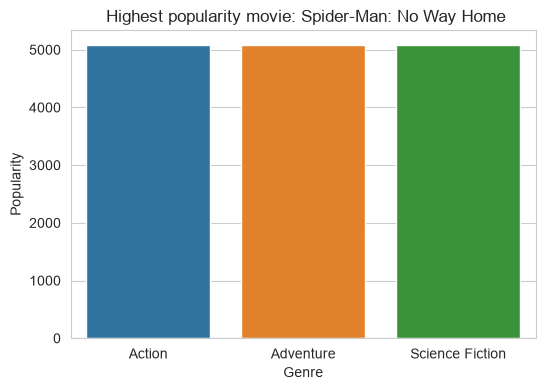

In [87]:
#top=df.loc[df['Popularity'].idxmax()]
top=df[df['Popularity']==df['Popularity'].max()][['Title','Popularity','Genre']]
plt.figure(figsize=(6,4))
sns.barplot(y='Popularity',hue='Genre',x='Genre',data=top)
movie=top['Title'].iloc[0]
plt.title(f' Highest popularity movie: {movie}')
plt.xlabel("Genre")
plt.ylabel("Popularity")
plt.show()


# what movie got the lowest popularity ? what's its genre ?

In [88]:
df[df['Popularity']==df['Popularity'].min()][['Title','Popularity','Genre']]

,Title,Popularity,Genre
23912,The Story of Star Wars,13.0,Documentary
23913,Terra Formars,13.0,Action
23914,Terra Formars,13.0,Horror
23915,Terra Formars,13.0,Science Fiction
23916,Haikyuu!! Movie 2: Winners and Losers,13.0,Animation
...,...,...,...
25547,The United States vs. Billie Holiday,13.0,Drama
25548,The United States vs. Billie Holiday,13.0,History
25549,Threads,13.0,War
25550,Threads,13.0,Drama


# which year has the most filmmed movies ?

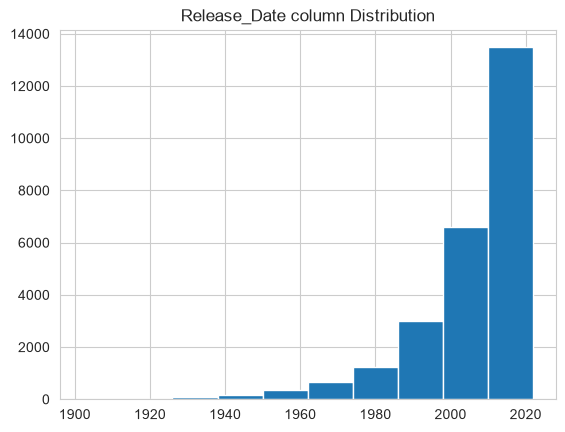

In [90]:
df['Release_Date'].hist()
plt.title('Release_Date column Distribution')
plt.show()